<a href="https://colab.research.google.com/github/abhijeetkumar6225/Plant_disease_prediction/blob/main/plant_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
dataset_url = "https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset"

In [54]:
dataset_url

'https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset'

In [55]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'sample_data']


In [56]:
import os

print(os.listdir("/kaggle/input"))

['new-plant-diseases-dataset']


In [57]:
for root, dirs, files in os.walk('/content'):
    if 'train' in dirs:
        print(root)

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print(path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
/kaggle/input/new-plant-diseases-dataset


In [60]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


In [61]:
#Validation image preprocessing

In [62]:
validation_set= tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
     labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 17572 files belonging to 38 classes.


In [63]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[136.25 145.25 178.25]
   [137.75 146.75 179.75]
   [135.   144.   177.  ]
   ...
   [124.75 133.75 162.75]
   [122.5  131.5  160.5 ]
   [129.75 138.75 167.75]]

  [[130.5  139.5  172.5 ]
   [135.25 144.25 177.25]
   [133.5  142.5  175.5 ]
   ...
   [127.5  136.5  165.5 ]
   [128.   137.   166.  ]
   [132.   141.   170.  ]]

  [[135.75 144.75 177.75]
   [137.75 146.75 179.75]
   [135.   144.   177.  ]
   ...
   [130.5  139.5  168.5 ]
   [134.75 143.75 172.75]
   [128.5  137.5  166.5 ]]

  ...

  [[ 90.25  92.25 117.25]
   [ 98.5  100.5  125.5 ]
   [100.   102.   127.  ]
   ...
   [ 31.5   21.    20.  ]
   [ 41.25  28.75  27.25]
   [ 48.    34.    32.5 ]]

  [[ 80.75  82.75 107.75]
   [108.25 110.25 135.25]
   [ 83.25  85.25 110.25]
   ...
   [ 44.75  35.25  36.75]
   [ 51.5   40.    43.  ]
   [ 51.5   40.    43.5 ]]

  [[100.75 102.75 127.75]
   [101.25 103.25 128.25]
   [ 98.   100.   125.  ]
   ...
   [ 54.75  49.25  52.75]
   [ 58.    52.5   57.5 ]
   [ 59.    53.25  5

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    BatchNormalization
)

In [65]:
model= Sequential()


In [66]:
#Building Convolutional layer

In [67]:
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))


In [68]:
model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [69]:
model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [70]:
model.add(Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [71]:
model.add(Conv2D(filters=512,kernel_size=(3,3),padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2))

In [72]:
model.add(Dropout(0.25))

In [73]:
model.add(Flatten())

In [74]:
model.add(Dense(units=1024,activation='relu'))

In [75]:
model.add(Dropout(0.4))

In [76]:
model.add(Dense(38, activation='softmax'))

In [77]:
#compiling model

In [78]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849,350 (26.13 MB)

 Trainable params: 6,849,350 (26.13 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
#model training

In [81]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 171s 74ms/step - accuracy: 0.5756 - loss: 1.4502 - val_accuracy: 0.8243 - val_loss: 0.5626
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 158s 72ms/step - accuracy: 0.8492 - loss: 0.4841 - val_accuracy: 0.8848 - val_loss: 0.3632
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 160s 73ms/step - accuracy: 0.9069 - loss: 0.2901 - val_accuracy: 0.9328 - val_loss: 0.2113
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 158s 72ms/step - accuracy: 0.9355 - loss: 0.2019 - val_accuracy: 0.9496 - val_loss: 0.1560
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9528 - loss: 0.1460 - val_accuracy: 0.9578 - val_loss: 0.1352
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 178s 81ms/step - accuracy: 0.9636 - loss: 0.1129 - val_accuracy: 0.9574 - val_loss: 0.1408
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 159s 72ms/step - accuracy: 0.9699 - loss: 0.0937 - val_accuracy: 0.9541 - val_loss: 0.1520
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 158s 72ms/step - accuracy: 

In [82]:
#model evaluation

In [83]:
train_loss,train_accuracy=model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 170s 77ms/step - accuracy: 0.9930 - loss: 0.0209


In [84]:
print(f"Training Loss: {train_loss}")
print(f"Training Accuracy: {train_accuracy}")

Training Loss: 0.020919514819979668
Training Accuracy: 0.9929582476615906


In [86]:
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_acc}")

Validation Loss: 0.09933363646268845
Validation Accuracy: 0.9709765315055847


In [87]:
# saving model

In [88]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [89]:
model.save("plant_disease_model.keras")

38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target

In [91]:
from google.colab import files

In [93]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'sample_data']


In [94]:
print(os.listdir('/content'))

['.config', 'drive', 'sample_data']


In [95]:
model.save("plant_disease_model.keras")

In [96]:
import os
print(os.path.exists("plant_disease_model.keras"))

True


In [97]:
from google.colab import files

files.download("plant_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

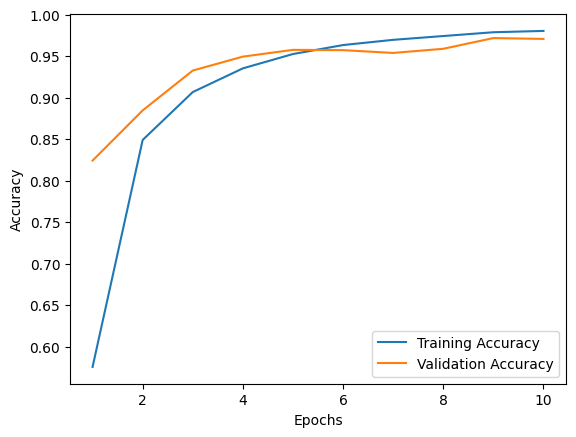

In [98]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [102]:
training_history.history


{'accuracy': [0.5755743384361267,
  0.8491642475128174,
  0.9069066047668457,
  0.9354861378669739,
  0.9527562260627747,
  0.9635820388793945,
  0.96986985206604,
  0.9744505286216736,
  0.9790170192718506,
  0.9806103110313416],
 'loss': [1.4501889944076538,
  0.4841400384902954,
  0.2901497781276703,
  0.20190030336380005,
  0.14599840342998505,
  0.11286897957324982,
  0.09366471320390701,
  0.07784831523895264,
  0.06589515507221222,
  0.058875709772109985],
 'val_accuracy': [0.8243227601051331,
  0.8848167657852173,
  0.9328477382659912,
  0.9496358036994934,
  0.957773745059967,
  0.9574322700500488,
  0.9540746808052063,
  0.9590826034545898,
  0.9720008969306946,
  0.9709765315055847],
 'val_loss': [0.5625725388526917,
  0.3631848394870758,
  0.21128898859024048,
  0.15604087710380554,
  0.13521984219551086,
  0.14075124263763428,
  0.15196183323860168,
  0.13639335334300995,
  0.09070637822151184,
  0.09933363646268845]}

In [118]:
test_set= tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/test',
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(128,128),
    shuffle=False,
    seed=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False
)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/test'

In [108]:
y_pred= model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 49s 88ms/step


(array([[9.99998927e-01, 1.11302498e-07, 4.65048527e-10, ...,
         5.17926305e-13, 7.53046714e-13, 3.94663859e-12],
        [9.99966621e-01, 2.09167138e-06, 2.59343574e-10, ...,
         2.48266100e-12, 1.49684057e-13, 1.35786618e-12],
        [1.00000000e+00, 1.24391226e-08, 5.15718267e-11, ...,
         1.50503024e-16, 3.84894238e-13, 1.91813430e-13],
        ...,
        [3.82430621e-09, 1.14552074e-11, 3.33175976e-09, ...,
         1.10238534e-10, 6.68416655e-10, 9.99998689e-01],
        [8.37211689e-11, 2.14428966e-14, 8.94671351e-11, ...,
         3.70008191e-12, 1.28353344e-11, 1.00000000e+00],
        [1.33624719e-12, 8.05185962e-15, 3.39236560e-14, ...,
         1.05714455e-13, 7.87620403e-12, 9.99999881e-01]], dtype=float32),
 (17572, 38))

In [109]:
predicted_categories=tf.argmax(y_pred,axis=1)


In [110]:
true_categories=tf.concat([y for x,y in test_set],axis=0)

In [112]:
y_true=tf.argmax(true_categories,axis=1)


In [113]:
from sklearn.metrics import classification_report

In [119]:
class_names = test_set.class_names
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [120]:
print(classification_report(y_true,predicted_categories,output_dict=False, target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.97      0.97       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       0.98      0.98      0.98       440
                                   Apple___healthy       0.97      0.97      0.97       502
                               Blueberry___healthy       0.96      0.99      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       421
                 Cherry_(including_sour)___healthy       0.98      1.00      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.96      0.95       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.96      0.

In [122]:
from sklearn.metrics import confusion_matrix

In [123]:
cm=confusion_matrix(y_true,predicted_categories)
cm

array([[489,   3,   0, ...,   0,   0,   0],
       [  1, 493,   0, ...,   0,   0,   0],
       [  0,   0, 431, ...,   0,   0,   1],
       ...,
       [  0,   0,   0, ..., 478,   0,   0],
       [  0,   0,   0, ...,   0, 446,   0],
       [  0,   0,   0, ...,   0,   0, 477]])

Text(470.72222222222223, 0.5, 'Actual')

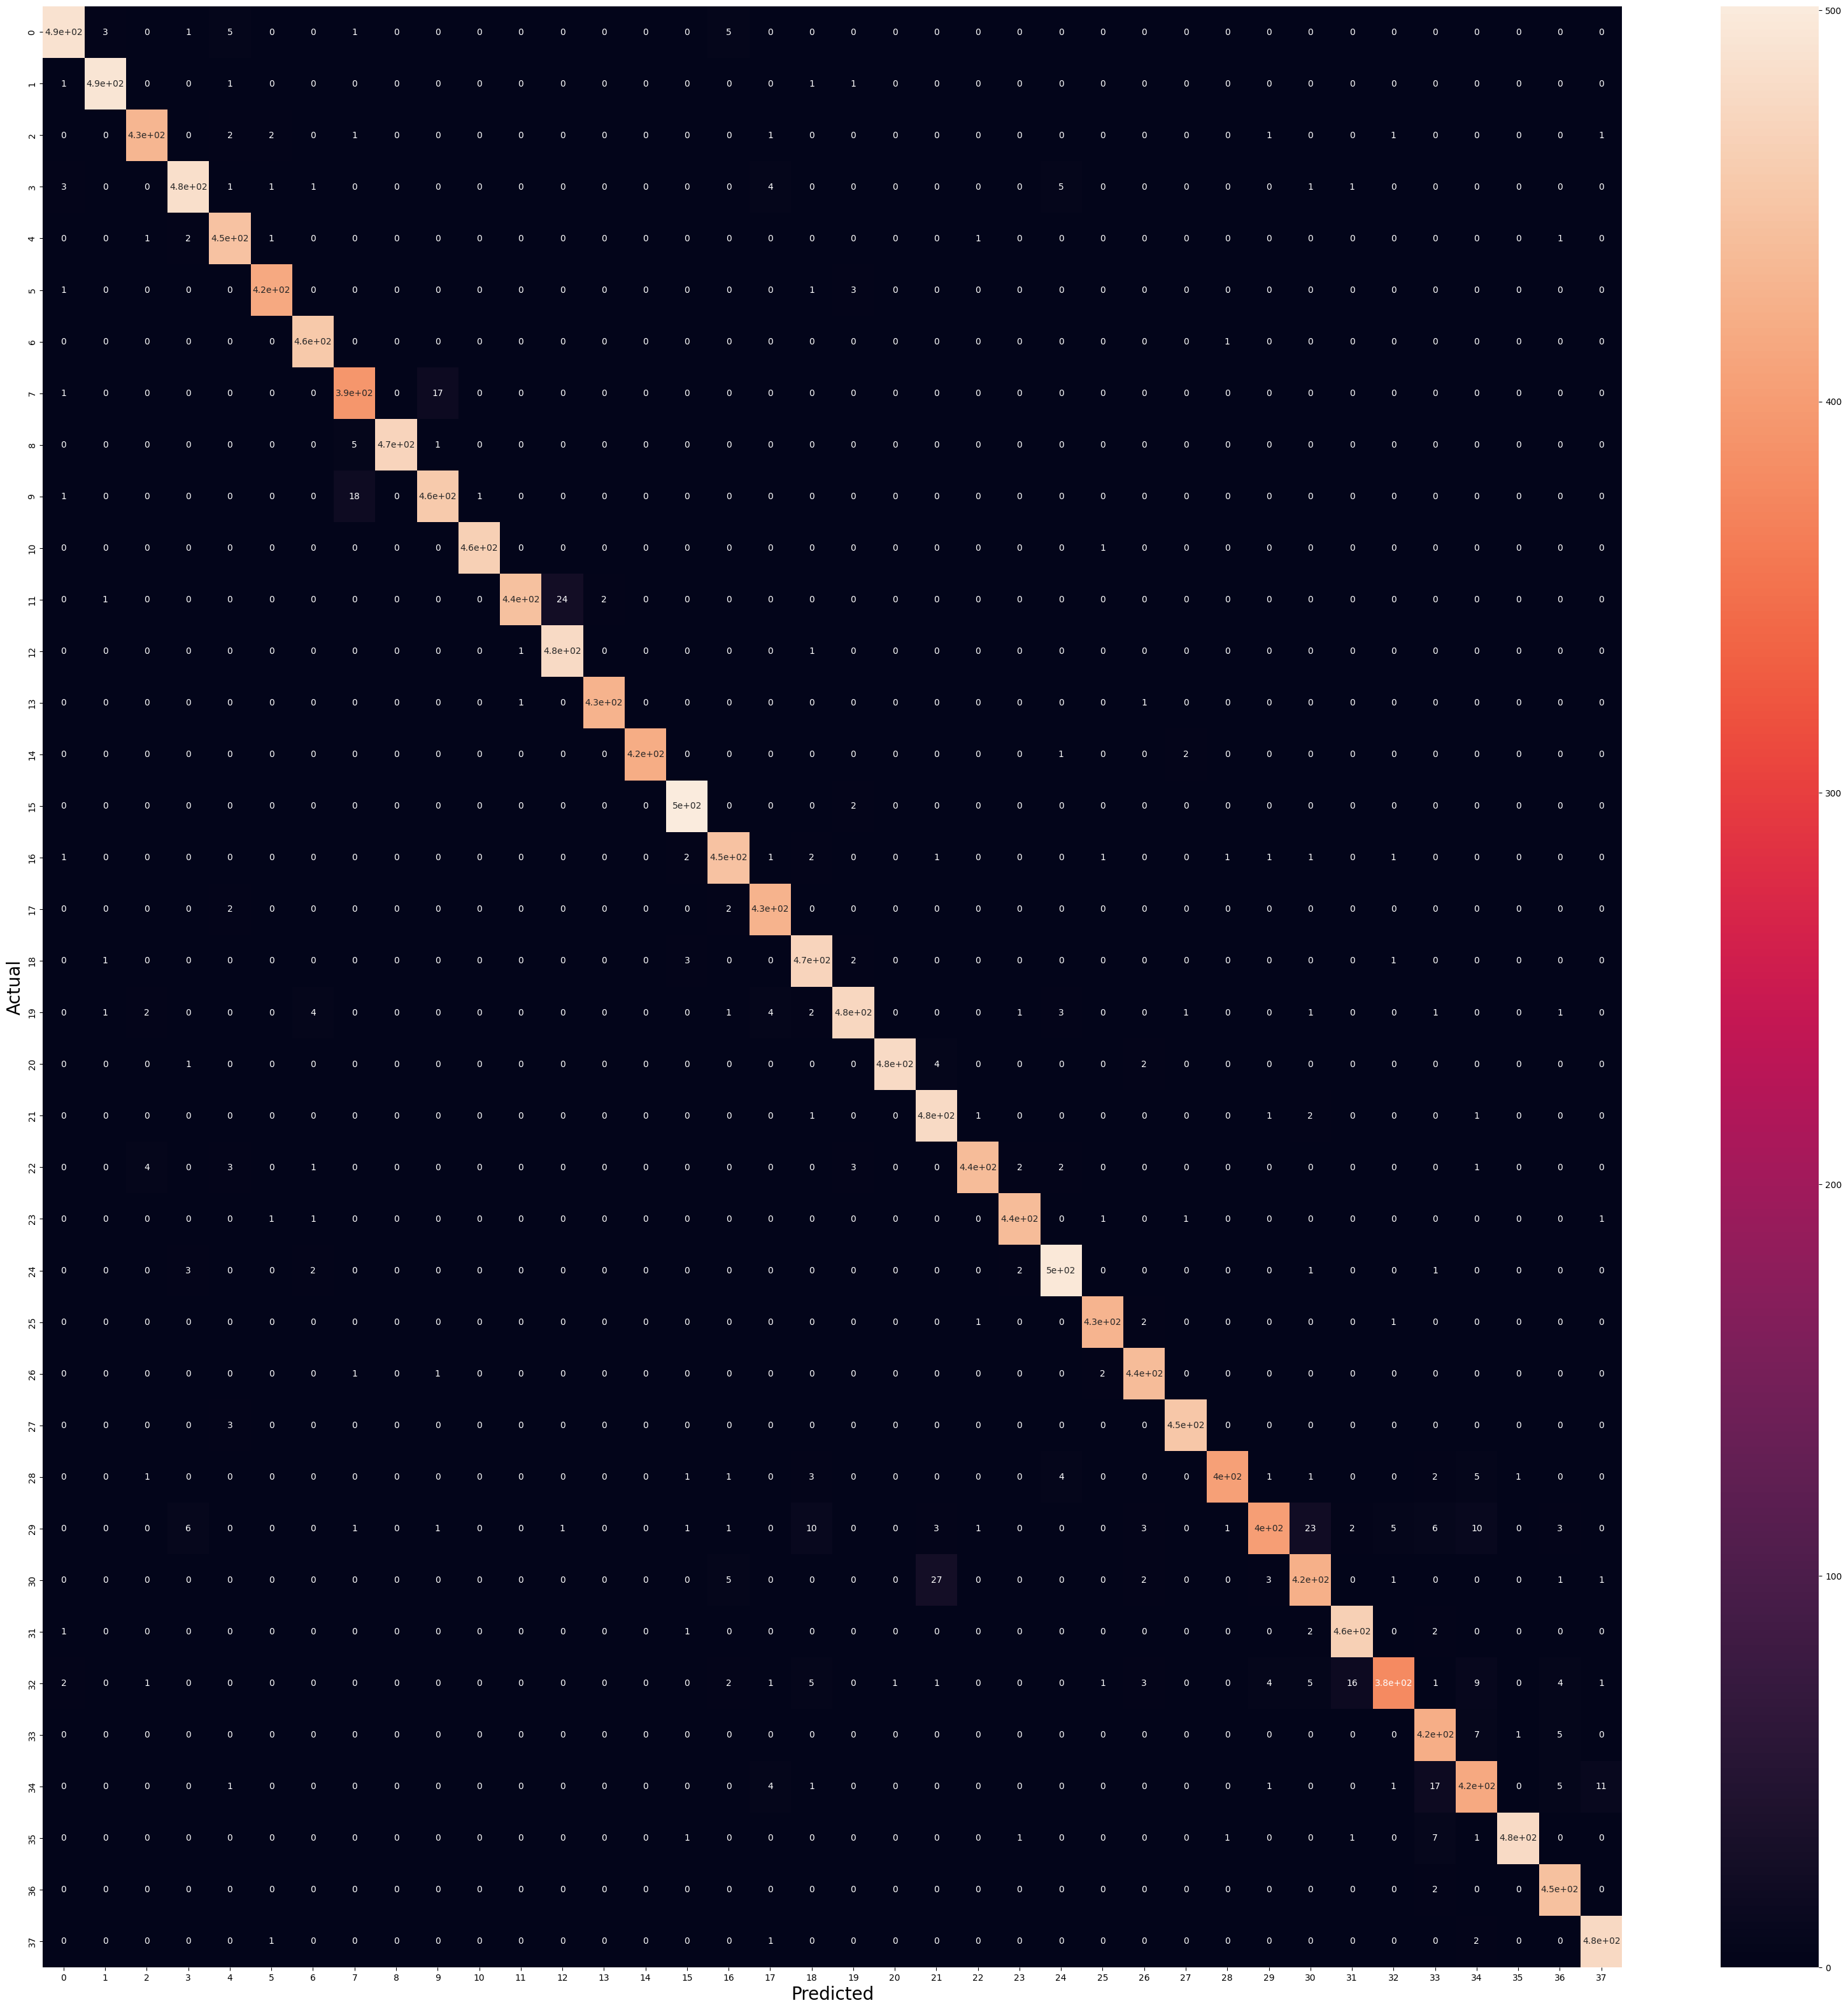

In [127]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('Actual', fontsize=20)